In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [2]:
import seaborn as sns 
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd

In [3]:
iris = load_iris()

In [4]:
X = iris.data
y = iris.target

<Axes: >

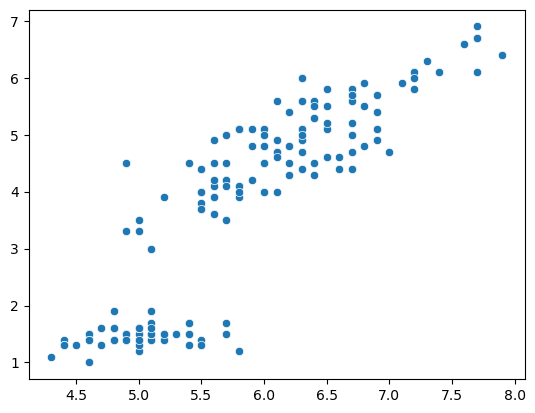

In [5]:
# Visualize data 
# the data has 4 features but we are visulizing it in 2d using only 2 fetures 

sns.scatterplot(x=X[:,0],y=X[:,2] )

## Data Scalling

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
# Dimensionality Reduction using PCA 

from sklearn.decomposition import PCA

pca = PCA(n_components = 2)

pca_data = pca.fit_transform(X_scaled)

In [13]:
# ELBOW METHOD 

wcss = []# Within-Cluster Sum of Squares

for k in range (1 , 11):
    kmeans = KMeans (
    n_clusters=k,
    random_state = 42
    )
    labels  = kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)
    

<Axes: >

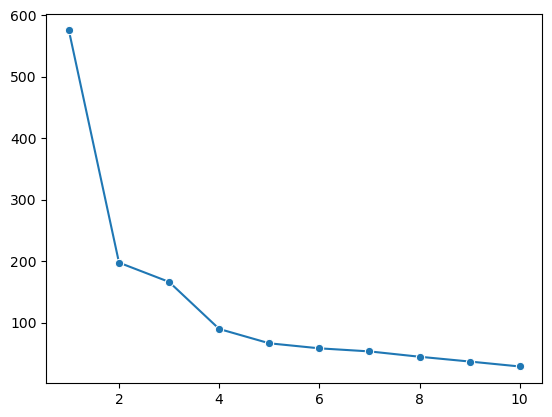

In [14]:
sns.lineplot(x= range(1,11),y=wcss,marker = 'o')

<Axes: >

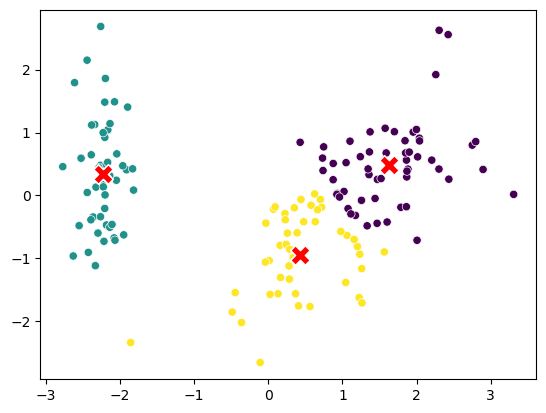

In [24]:
# KMeans

kmeans = KMeans(n_clusters =3, random_state = 10)
labels =  kmeans.fit_predict(pca_data)

sns.scatterplot(x = pca_data[:,0],y = pca_data[:,1], c = labels)
sns.scatterplot(x= kmeans.cluster_centers_[:,0],y=kmeans.cluster_centers_[:,1],marker = "X",c = "red", s=200)